# Bayesiaanse afspeellijstaanbeveling

**Project R.E.M. -- Notebook 2 van 4**

## Doel

Dit notebook traint een **hierarchisch Bayesiaans regressiemodel** dat per deelnemer
de beste afspeellijst (Calm / Neutral / Energy) voorspelt op basis van stemming en biometrie.

**Onderzoeksvraag (RQ4, novel contribution):** *Gegeven de huidige fysiologische toestand
van een deelnemer, welk playlisttype produceert de beste stemmingsuitkomst?*

> **Interpretatiewaarschuwing:** Met N≤42 sessies per deelnemer overlappen de posterieure
> betrouwbaarheidsintervallen voor alle 6 deelnemers sterk. Aanbevelingen zijn **richtinggevend,
> geen zekerheden**. Brede intervallen zijn correct — ze reflecteren de werkelijke onzekerheid.
>
> Bovendien heeft Energy de meeste sessies (n=48 vs Calm n=34, Neutral n=23). Klassenonevenwicht
> kan de posterior voor Energy opblazen. Zie sectie 3 voor een uitsplitsing per deelnemer.

## Waarom een hierarchisch Bayesiaans model?

Met N=6 deelnemers en gemiddeld ~15 sessies per persoon is een individueel model per deelnemer
te gevoelig voor overfitting. Een **hierarchisch model met partiele pooling** lost dit op:
- Deelnemers delen groepsniveau priors (mu_playlist, mu_alpha)
- Individuele effecten worden geschat maar getrokken richting het groepsgemiddelde
- Deelnemers met weinig sessies profiteren van informatie uit andere deelnemers
- De posterior breedte reflecteert de echte onzekerheid bij kleine N

## Modelformule

```
mood_delta ~ Normal(mu, sigma)
mu = alpha[deelnemer] + beta_playlist[deelnemer, type]
   + bio_mask * (beta_stress*stress_z + beta_bb*bb_z + beta_hr*hr_z)
   + beta_hour * hour_z
```

Non-centered parameterisatie voorkomt divergenties bij kleine N.
`bio_mask = 0` voor check-in-only deelnemers zonder smartwatch.

## Gebruik

| Instelling | Betekenis |
|---|---|
| `REUSE_MODEL = True` | Laad opgeslagen trace vanuit `models/bayesian_recommender/` (snel) |
| `REUSE_MODEL = False` | Sample opnieuw via NumPyro/JAX (~30 s) |
| `PARTICIPANT = "all"` | Analyse voor alle deelnemers |

**Vereisten:** voer eerst uit:
```bash
uv run python scripts/baseline/pipeline.py --all
uv run python scripts/sessions/pipeline.py --all
```

In [40]:
# Samplingparameters
REUSE_MODEL   = False    # True -> laad trace, False -> sample opnieuw (~30 s)
DRAWS         = 1000    # posterior samples per chain
TUNE          = 500     # warmup steps voor NUTS
CHAINS        = 4       # parallelle Markov-ketens
TARGET_ACCEPT = 0.9     # NUTS acceptatierate; hogere waarde = voorzichtiger stap

# Gevoeligheidsanalyse: deelnemer om te analyseren (of "all" -> auto-selecteer)
PARTICIPANT = "all"

## 1. Setup

In [41]:
import json
import warnings
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='Glyph .* missing from font')

PROJECT_ROOT = Path().resolve().parent.parent
DATA_ROOT    = PROJECT_ROOT / 'data'
MODELS_DIR   = PROJECT_ROOT / 'models' / 'bayesian_recommender'
BAYES_OUT    = DATA_ROOT / 'analysis' / 'bayesian_recommender'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
BAYES_OUT.mkdir(parents=True, exist_ok=True)

PLAYLIST_MAP   = {'Calm': 0, 'Neutral': 1, 'Energy': 2}
PLAYLIST_NAMES = ['Calm', 'Neutral', 'Energy']

# Kleurpalet per deelnemer (codenames zijn fruitnamen voor anonimisering)
PARTICIPANTS = {
    'bosbes':     {'color': '#6A5ACD'},
    'kokosnoot':  {'color': '#8B4513'},
    'limoen':     {'color': '#32CD32'},
    'peer':       {'color': '#DAA520'},
    'kiwi':       {'color': '#556B2F'},
    'watermeloen':{'color': '#DC143C'},
}
PLAYLIST_COLORS = {'Calm': '#4A90D9', 'Neutral': '#7B7B7B', 'Energy': '#E8913A'}

# Donker thema (consistent met Shiny-app)
plt.rcParams.update({
    'figure.facecolor': '#0f1218', 'axes.facecolor': '#181e2a',
    'axes.edgecolor':   '#232b3a', 'axes.labelcolor': '#c9d1d9',
    'axes.grid': True, 'grid.color': '#232b3a', 'grid.linewidth': 0.5,
    'text.color': '#c9d1d9', 'xtick.color': '#586475', 'ytick.color': '#586475',
    'legend.facecolor': '#181e2a', 'legend.edgecolor': '#232b3a',
    'font.family': 'monospace', 'font.size': 9, 'figure.dpi': 120,
})

## 2. Hulpfuncties

In [42]:
# Valentiekaart: Nederlandse emotienamen -> score (-1, 0, +1)
VALENCE_MAP = {
    'gestresseerd of gespannen': -1, 'moe of ongemotiveerd': -1, 'moe en gespannen...': -1,
    'neutraal': 0, 'neutraal tot een goed gevoel': 0,
    'rustig': 1, 'gemotiveerd': 1, 'happy': 1, 'happy - gemotiveerd': 1, 'goed gevoel': 1,
}

def emotion_valence(emotion: str) -> int:
    """Map emotienaam naar valentie (-1=negatief, 0=neutraal, +1=positief)."""
    key = emotion.strip().lower()
    if key in VALENCE_MAP:
        return VALENCE_MAP[key]
    if any(w in key for w in ('stress', 'gespannen', 'moe', 'ongemot')):
        return -1
    if any(w in key for w in ('happy', 'goed', 'gemotiv', 'rustig', 'blij')):
        return 1
    return 0

def composite_mood(emotion: str, intensity: float) -> float:
    """Valentie-gewogen stemmingsscore: valentie * intensiteit."""
    return emotion_valence(emotion) * intensity

In [43]:
def load_biometric_sessions(codename: str) -> pd.DataFrame:
    """Laad session_biometrics.csv voor een deelnemer met smartwatchdata."""
    path = DATA_ROOT / 'wearables' / codename / 'processed' / 'session_biometrics.csv'
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    df['participant'] = codename
    df['has_biometrics'] = True
    return df


def load_checkin_sessions() -> pd.DataFrame:
    """Laad check-in CSV en bereken stemmingsscores voor alle deelnemers."""
    for checkin_path in [
        DATA_ROOT / 'check_in' / 'check_in.csv',
        DATA_ROOT / 'checkins' / 'Check-in_formulier_REM.csv',
    ]:
        if checkin_path.exists():
            break
    else:
        raise FileNotFoundError('Geen check-in CSV gevonden')

    ci = pd.read_csv(checkin_path)
    rows = []
    for _, r in ci.iterrows():
        emotion_before   = str(r['Welk gevoel had je?'])
        emotion_after    = str(r['Welk gevoel had je?.1'])
        intensity_before = float(r['Score van de intensiteit van je gevoel'])
        intensity_after  = float(r['Score van de intensiteit van je gevoel.1'])
        playlist_raw = str(r['Welke playlist luisterde je?'])
        playlist = playlist_raw.strip().capitalize()
        if playlist not in PLAYLIST_MAP:
            continue
        start_str = str(r.get('Starttijd?', ''))
        try:
            hour = pd.to_datetime(start_str, format='%H:%M:%S').hour
        except Exception:
            try:
                hour = int(start_str.split(':')[0])
            except Exception:
                hour = 12
        rows.append({
            'participant':           str(r['Deelnemerscode']).strip().lower(),
            'playlist':              playlist,
            'emotion_before':        emotion_before,
            'emotion_after':         emotion_after,
            'intensity_before':      intensity_before,
            'intensity_after':       intensity_after,
            'mood_before_composite': composite_mood(emotion_before, intensity_before),
            'mood_after_composite':  composite_mood(emotion_after, intensity_after),
            'hour_of_day':           hour,
        })
    df = pd.DataFrame(rows)
    df['mood_delta'] = df['mood_after_composite'] - df['mood_before_composite']
    return df


def _load_feature_matrix() -> pd.DataFrame | None:
    """Laad circadiaan feature matrix als beschikbaar (geeft basisafwijkingen)."""
    fm_path = DATA_ROOT / 'analysis' / 'circadian_baselines' / 'feature_matrix.csv'
    if not fm_path.exists():
        return None
    fm = pd.read_csv(fm_path)
    fm['date'] = pd.to_datetime(fm['date']).dt.date
    return fm


def build_model_data(participants_with_bio):
    """
    Combineer biometrische sessies en check-in-only sessies in een DataFrame.
    Deelnemers met biometrie krijgen volledige feature vectors.
    Check-in-only deelnemers dragen bij via stemming + playlisteffecten (biometrie = NaN).
    """
    checkin_df = load_checkin_sessions()
    fm = _load_feature_matrix()
    use_circadian = fm is not None
    if use_circadian:
        print('  Circadiane basisafwijkingen worden gebruikt (feature_matrix.csv).')
    else:
        print('  WAARSCHUWING: feature_matrix.csv niet gevonden -- ruwe stress/HR wordt gebruikt.')
        print('  Voer scripts/baseline/pipeline.py uit voor circadiane correctie.')

    bio_frames = []
    bio_participants = set()

    if participants_with_bio:
        for code in participants_with_bio:
            bio = load_biometric_sessions(code)
            if bio.empty:
                continue
            bio_participants.add(code)
            if use_circadian:
                bio['_date'] = pd.to_datetime(bio['date'], errors='coerce').dt.date
                fm_part = fm[fm['participant'] == code].copy()
            bio_rows = []
            for _, r in bio.iterrows():
                ci_match = checkin_df[
                    (checkin_df['participant'] == code)
                    & (checkin_df['playlist'] == r['playlist'])
                ]
                if not ci_match.empty:
                    ci_row = ci_match.iloc[0]
                    mood_before_comp = ci_row['mood_before_composite']
                    mood_after_comp  = ci_row['mood_after_composite']
                    mood_delta       = ci_row['mood_delta']
                else:
                    mood_before_comp = 0.0
                    mood_after_comp  = 0.0
                    mood_delta = float(r['mood_after_score']) - float(r['mood_before_score'])
                stress_val = r.get('pre_stress_mean')
                hr_val     = r.get('pre_hr_mean')
                if use_circadian:
                    row_date = r.get('_date') if '_date' in r.index else None
                    if row_date is not None:
                        fm_match = fm_part[fm_part['date'] == row_date]
                        if not fm_match.empty:
                            fm_row     = fm_match.iloc[0]
                            stress_val = fm_row.get('baseline_deviation_entry')
                            hr_val     = fm_row.get('hr_baseline_deviation')
                bio_rows.append({
                    'participant':           code,
                    'playlist':              r['playlist'],
                    'mood_delta':            mood_delta,
                    'mood_before_composite': mood_before_comp,
                    'mood_after_composite':  mood_after_comp,
                    'baseline_deviation':    stress_val,
                    'bb_start':              r.get('bb_start'),
                    'hr_baseline_deviation': hr_val,
                    'hour_of_day': pd.to_datetime(r.get('start_local', '12:00'),
                                                  errors='coerce').hour
                        if pd.notna(r.get('start_local')) else 12,
                    'has_biometrics': True,
                })
            if bio_rows:
                bio_frames.append(pd.DataFrame(bio_rows))

    ci_only = checkin_df[~checkin_df['participant'].isin(bio_participants)].copy()
    ci_only['has_biometrics']        = False
    ci_only['baseline_deviation']    = np.nan
    ci_only['bb_start']              = np.nan
    ci_only['hr_baseline_deviation'] = np.nan

    all_frames = bio_frames + ([ci_only] if not ci_only.empty else [])
    if not all_frames:
        raise ValueError('Geen sessiedata gevonden')

    combined = pd.concat(all_frames, ignore_index=True)
    combined['playlist_idx'] = combined['playlist'].map(PLAYLIST_MAP)
    participant_codes = sorted(combined['participant'].unique())
    participant_map   = {p: i for i, p in enumerate(participant_codes)}
    combined['participant_idx'] = combined['participant'].map(participant_map)
    return combined, participant_codes

In [44]:
def build_hierarchical_model(data: pd.DataFrame, participant_codes):
    """
    Bouw het hierarchisch Bayesiaans regressiemodel.

    Non-centered parameterisatie: alpha = mu_alpha + sigma_alpha * alpha_offset
    Dit voorkomt 'funnel' geometrie die NUTS-divergenties veroorzaakt bij kleine N.
    bio_mask = 0 voor check-in-only deelnemers, zodat biometrische coefficienten
    niet bijdragen voor deelnemers zonder smartwatch.
    Zie: https://www.pymc.io/projects/docs/en/stable/learn/core_notebooks/pymc_overview.html
    """
    n_participants = len(participant_codes)
    n_playlists    = 3

    # Standardiseer covariaten (z-scores) -- voorkomt schaalverschillen in posterior
    z_cols = {}
    for col in ['baseline_deviation', 'bb_start', 'hr_baseline_deviation']:
        vals = data[col].copy()
        mu, sd = vals.mean(), vals.std()
        if pd.isna(mu) or sd == 0 or pd.isna(sd):
            z_cols[f'{col}_z'] = np.zeros(len(data))
        else:
            z_cols[f'{col}_z'] = ((vals.fillna(mu) - mu) / sd).values

    hour_mu, hour_sd = data['hour_of_day'].mean(), data['hour_of_day'].std()
    if hour_sd == 0:
        hour_sd = 1.0
    z_cols['hour_z'] = ((data['hour_of_day'] - hour_mu) / hour_sd).values

    bio_mask        = data['has_biometrics'].astype(float).values
    y               = data['mood_delta'].values.astype(float)
    participant_idx = data['participant_idx'].values.astype(int)
    playlist_idx    = data['playlist_idx'].values.astype(int)

    stress_z = z_cols['baseline_deviation_z']
    bb_z     = z_cols['bb_start_z']
    hr_z     = z_cols['hr_baseline_deviation_z']
    hour_z   = z_cols['hour_z']

    with pm.Model() as model:
        # Sla metadata op voor recommend_playlist
        model._participant_codes = participant_codes
        model._z_params = {
            'stress_mu': float(data['baseline_deviation'].mean())
                if data['baseline_deviation'].notna().any() else 0,
            'stress_sd': float(data['baseline_deviation'].std())
                if data['baseline_deviation'].notna().any() else 1,
            'bb_mu': float(data['bb_start'].mean())
                if data['bb_start'].notna().any() else 0,
            'bb_sd': float(data['bb_start'].std())
                if data['bb_start'].notna().any() else 1,
            'hr_mu': float(data['hr_baseline_deviation'].mean())
                if data['hr_baseline_deviation'].notna().any() else 0,
            'hr_sd': float(data['hr_baseline_deviation'].std())
                if data['hr_baseline_deviation'].notna().any() else 1,
            'hour_mu': float(hour_mu),
            'hour_sd': float(hour_sd),
        }

        # Groepsniveau priors
        mu_alpha       = pm.Normal('mu_alpha',    mu=0, sigma=5)
        sigma_alpha    = pm.HalfNormal('sigma_alpha', sigma=2)
        mu_playlist    = pm.Normal('mu_playlist', mu=0, sigma=5, shape=n_playlists)
        sigma_playlist = pm.HalfNormal('sigma_playlist', sigma=2)

        # Non-centered deelnemerspecifieke effecten
        alpha_offset = pm.Normal('alpha_offset', mu=0, sigma=1, shape=n_participants)
        alpha = pm.Deterministic('alpha', mu_alpha + sigma_alpha * alpha_offset)

        beta_playlist_offset = pm.Normal(
            'beta_playlist_offset', mu=0, sigma=1,
            shape=(n_participants, n_playlists),
        )
        beta_playlist = pm.Deterministic(
            'beta_playlist',
            mu_playlist + sigma_playlist * beta_playlist_offset,
        )

        # Gedeelde biometrische coefficienten (alle deelnemers met smartwatch)
        beta_stress = pm.Normal('beta_stress', mu=0, sigma=2)
        beta_bb     = pm.Normal('beta_bb',     mu=0, sigma=2)
        beta_hr     = pm.Normal('beta_hr',     mu=0, sigma=2)
        beta_hour   = pm.Normal('beta_hour',   mu=0, sigma=2)

        mu_pred = (
            alpha[participant_idx]
            + beta_playlist[participant_idx, playlist_idx]
            + bio_mask * (
                beta_stress * stress_z
                + beta_bb * bb_z
                + beta_hr * hr_z
            )
            + beta_hour * hour_z
        )

        sigma = pm.HalfNormal('sigma', sigma=5)
        pm.Normal('mood_delta_obs', mu=mu_pred, sigma=sigma, observed=y)

    return model


def fit_model(model, draws=1000, tune=500, chains=4, target_accept=0.9):
    """Start NUTS sampler via NumPyro/JAX met PyMC fallback."""
    import pymc.sampling.jax as pmjax
    with model:
        try:
            trace = pmjax.sample_numpyro_nuts(
                draws=draws, tune=tune, chains=chains,
                target_accept=target_accept, random_seed=42,
            )
        except Exception as e:
            print(f'  JAX sampling mislukt ({e}), terugvallen op PyMC NUTS...')
            trace = pm.sample(
                draws=draws, tune=tune, chains=chains,
                target_accept=target_accept,
                return_inferencedata=True, random_seed=42,
            )
    return trace


def export_streamlit_json(trace, model, out_path: Path):
    """Exporteer per-deelnemer x playlist posterieure samenvattingen als JSON voor de Shiny-app."""
    codes  = model._participant_codes
    result = {}
    for p_idx, participant in enumerate(codes):
        result[participant] = {}
        posterior = trace.posterior
        for k, name in enumerate(PLAYLIST_NAMES):
            alpha_samples = posterior['alpha'].values[:, :, p_idx].flatten()
            bp_samples    = posterior['beta_playlist'].values[:, :, p_idx, k].flatten()
            predicted     = alpha_samples + bp_samples
            result[participant][name] = {
                'mean':    round(float(np.mean(predicted)), 2),
                'ci_low':  round(float(np.percentile(predicted, 5.5)), 2),
                'ci_high': round(float(np.percentile(predicted, 94.5)), 2),
            }
    with open(out_path, 'w') as f:
        json.dump(result, f, indent=2)
    print(f'  -> {out_path}')
    return result


def recommend_playlist(
    trace, model, participant_id: str,
    pre_stress=None, bb_start=None, pre_hr=None,
    hour_of_day: int = 12,
) -> dict:
    """
    Voorspel mood_delta voor elk playlisttype en retourneer een aanbeveling.

    Gebruikt de posterior om per playlist de verwachte stemmingsverbetering
    te berekenen, inclusief betrouwbaarheidsinterval (89% HDI).
    Markeert de aanbeveling als onzeker als de intervallen sterk overlappen.
    """
    codes = model._participant_codes
    zp    = model._z_params

    if participant_id not in codes:
        raise ValueError(f"Onbekende deelnemer '{participant_id}'. Bekend: {codes}")

    p_idx   = codes.index(participant_id)
    has_bio = pre_stress is not None and bb_start is not None

    stress_z = (pre_stress - zp['stress_mu']) / zp['stress_sd'] if pre_stress is not None else 0
    bb_z     = (bb_start  - zp['bb_mu'])     / zp['bb_sd']     if bb_start  is not None else 0
    hr_z     = (pre_hr    - zp['hr_mu'])     / zp['hr_sd']     if pre_hr    is not None else 0
    hour_z   = (hour_of_day - zp['hour_mu']) / zp['hour_sd']
    bio_mask = 1.0 if has_bio else 0.0

    posterior           = trace.posterior
    alpha_samples       = posterior['alpha'].values[:, :, p_idx].flatten()
    beta_stress_samples = posterior['beta_stress'].values.flatten()
    beta_bb_samples     = posterior['beta_bb'].values.flatten()
    beta_hr_samples     = posterior['beta_hr'].values.flatten()
    beta_hour_samples   = posterior['beta_hour'].values.flatten()

    results   = {}
    all_means = {}

    for k, name in enumerate(PLAYLIST_NAMES):
        bp_samples = posterior['beta_playlist'].values[:, :, p_idx, k].flatten()
        predicted_delta = (
            alpha_samples + bp_samples
            + bio_mask * (
                beta_stress_samples * stress_z
                + beta_bb_samples   * bb_z
                + beta_hr_samples   * hr_z
            )
            + beta_hour_samples * hour_z
        )
        mean_delta      = float(np.mean(predicted_delta))
        ci_low, ci_high = np.percentile(predicted_delta, [5.5, 94.5])
        results[name]   = {
            'mean_delta': round(mean_delta, 2),
            'ci_low':     round(float(ci_low), 2),
            'ci_high':    round(float(ci_high), 2),
        }
        all_means[name] = mean_delta

    best             = max(all_means, key=all_means.get)
    sorted_playlists = sorted(all_means, key=all_means.get, reverse=True)

    if len(sorted_playlists) >= 2:
        best_ci   = results[sorted_playlists[0]]
        second_ci = results[sorted_playlists[1]]
        overlap   = min(best_ci['ci_high'], second_ci['ci_high']) - max(best_ci['ci_low'], second_ci['ci_low'])
        best_width = best_ci['ci_high'] - best_ci['ci_low']
        uncertain  = overlap > 0.5 * best_width if best_width > 0 else True
    else:
        uncertain = True

    best_k  = PLAYLIST_MAP[best]
    bp_best = posterior['beta_playlist'].values[:, :, p_idx, best_k].flatten()
    n_wins  = 0
    n_total = len(bp_best)
    for k, name in enumerate(PLAYLIST_NAMES):
        if name == best:
            continue
        bp_other = posterior['beta_playlist'].values[:, :, p_idx, k].flatten()
        n_wins  += np.sum(bp_best > bp_other)
    prob_best = n_wins / (n_total * (len(PLAYLIST_NAMES) - 1))

    recommendation = (
        f"{best} ({prob_best:.0%} kans op beste stemmingsverbetering)"
        + (" -- betrouwbaarheidsintervallen overlappen sterk; meer data nodig" if uncertain else "")
    )

    return {
        'participant':          participant_id,
        'predictions':          results,
        'recommendation':       recommendation,
        'recommended_playlist': best,
        'confidence':           round(float(prob_best), 2),
        'uncertain':            uncertain,
    }

## 3. Data laden

Deelnemers met smartwatch dragen bij via stemming + biometrische covariaten.
Check-in-only deelnemers dragen bij via stemming + playlisteffecten
(biometrische coefficienten zijn 0 voor hen via `bio_mask`).

Als `feature_matrix.csv` beschikbaar is, worden circadiane basisafwijkingen gebruikt
als stress/HR-maatstaven. Dit is de aanbevolen modus.

In [45]:
bio_participants = []
wearables_dir = DATA_ROOT / 'wearables'
if wearables_dir.exists():
    for d in sorted(wearables_dir.iterdir()):
        if (d / 'processed' / 'session_biometrics.csv').exists():
            bio_participants.append(d.name)

data, participant_codes = build_model_data(bio_participants)

print(f'Deelnemers met biometrie : {bio_participants or "(geen)"}')
print(f'Alle deelnemers          : {participant_codes}')
print(f'Totaal sessies           : {len(data)} ({int(data["has_biometrics"].sum())} bio, {int((~data["has_biometrics"]).sum())} check-in only)')
print()
print('Mood delta per afspeellijst:')
for pl in PLAYLIST_NAMES:
    sub = data[data['playlist'] == pl]['mood_delta']
    if not sub.empty:
        print(f'  {pl:8s}: n={len(sub):2d}, gem={sub.mean():+.1f}, bereik=[{sub.min():+.0f}, {sub.max():+.0f}]')

  Circadiane basisafwijkingen worden gebruikt (feature_matrix.csv).
Deelnemers met biometrie : ['bosbes', 'kokosnoot', 'limoen', 'peer', 'watermeloen']
Alle deelnemers          : ['bosbes', 'kiwi', 'kokosnoot', 'limoen', 'peer', 'watermeloen']
Totaal sessies           : 100 (95 bio, 5 check-in only)

Mood delta per afspeellijst:
  Calm    : n=34, gem=+2.3, bereik=[-2, +8]
  Neutral : n=20, gem=+2.3, bereik=[+0, +9]
  Energy  : n=46, gem=+9.0, bereik=[+0, +15]


In [46]:
# Sessieaantallen per deelnemer × playlisttype
print("Sessies per deelnemer × playlisttype:")
pivot = data.groupby(['participant', 'playlist']).size().unstack(fill_value=0)
for pl in PLAYLIST_NAMES:
    if pl not in pivot.columns:
        pivot[pl] = 0
pivot = pivot[PLAYLIST_NAMES]
pivot['Totaal'] = pivot.sum(axis=1)
display(pivot)

print("\nKlassenonevenwicht (totaal over alle deelnemers):")
for pl in PLAYLIST_NAMES:
    n = int(pivot[pl].sum())
    pct = n / len(data) * 100
    print(f"  {pl:10s}: n={n:2d} ({pct:.0f}%)")
print()
print("Let op: Energy heeft de meeste sessies. Dit kan de posterior richting Energy sturen,")
print("los van een werkelijk sterker effect.")

Sessies per deelnemer × playlisttype:


playlist,Calm,Neutral,Energy,Totaal
participant,,,,
bosbes,3,2,4,9
kiwi,1,1,3,5
kokosnoot,16,4,20,40
limoen,1,4,5,10
peer,12,7,11,30
watermeloen,1,2,3,6



Klassenonevenwicht (totaal over alle deelnemers):
  Calm      : n=34 (34%)
  Neutral   : n=20 (20%)
  Energy    : n=46 (46%)

Let op: Energy heeft de meeste sessies. Dit kan de posterior richting Energy sturen,
los van een werkelijk sterker effect.


## 4. Model bouwen en trace laden / samplen

Het model wordt altijd gebouwd (snel, geen sampling) om metadata te initialiseren
voor de `recommend_playlist` functie. De trace wordt daarna geladen of opnieuw gesampled.

In [47]:
trace_path = MODELS_DIR / 'trace.nc'

print('Model opbouwen...')
model = build_hierarchical_model(data, participant_codes)

if REUSE_MODEL:
    if not trace_path.exists():
        raise FileNotFoundError(
            f'Trace niet gevonden: {trace_path}\n'
            'Zet REUSE_MODEL = False om opnieuw te samplen.'
        )
    print(f'Trace laden uit {trace_path}...')
    trace = az.from_netcdf(str(trace_path))
else:
    print(f'Samplen ({CHAINS} chains x {DRAWS} draws, {TUNE} warmup)...')
    trace = fit_model(model, draws=DRAWS, tune=TUNE, chains=CHAINS, target_accept=TARGET_ACCEPT)
    trace.to_netcdf(str(trace_path))
    print(f'  -> {trace_path}')

print('Klaar.')

Model opbouwen...
Samplen (4 chains x 1000 draws, 500 warmup)...


  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 5. Diagnostiek

Drie convergentiecriteria voor een MCMC trace:

| Criterium | Drempel | Betekenis |
|---|---|---|
| **R-hat** | < 1.01 | Chains zijn het eens (convergentie) |
| **ESS bulk** | > 400 | Voldoende effectieve posterior samples |
| **Divergenties** | 0 | Sampler is niet vastgelopen in complexe geometrie |

Zie: [arviz diagnostics](https://python.arviz.org/en/stable/api/diagnostics.html)

In [ ]:
param_summary = az.summary(trace, hdi_prob=0.89)
rhat_ok = (param_summary['r_hat'] < 1.01).all()
ess_ok  = (param_summary['ess_bulk'] > 400).all()
n_div   = int(trace.sample_stats['diverging'].sum().values)

print(f"R-hat < 1.01 : {'PASS' if rhat_ok else 'FAIL'}")
print(f"ESS > 400    : {'PASS' if ess_ok  else 'FAIL'}")
print(f'Divergenties : {n_div}')
if not rhat_ok:
    print(f"  Hoge R-hat: {list(param_summary[param_summary['r_hat'] >= 1.01].index)}")
if not ess_ok:
    print(f"  Lage ESS  : {list(param_summary[param_summary['ess_bulk'] <= 400].index)}")
print()

key_params = [
    p for p in param_summary.index
    if any(k in p for k in ['mu_alpha', 'mu_playlist', 'sigma', 'beta_stress', 'beta_bb', 'beta_hr', 'beta_hour'])
    and 'offset' not in p and '[' not in p
]
display(param_summary.loc[key_params][['mean', 'sd', 'hdi_5.5%', 'hdi_94.5%', 'r_hat', 'ess_bulk']].round(2))

R-hat < 1.01 : PASS
ESS > 400    : PASS
Divergenties : 0



,mean,sd,hdi_5.5%,hdi_94.5%,r_hat,ess_bulk
mu_alpha,3.00,2.72,-1.21,7.46,1.0,2834.0
beta_stress,0.00,0.04,-0.06,0.06,1.0,5729.0
beta_bb,0.01,0.06,-0.08,0.11,1.0,4723.0
beta_hr,-0.00,0.04,-0.07,0.07,1.0,6771.0
beta_hour,0.01,0.05,-0.06,0.08,1.0,5141.0
sigma_alpha,2.84,0.99,1.44,4.62,1.0,1655.0
sigma_playlist,2.86,0.65,1.87,3.82,1.0,1603.0
sigma,0.28,0.02,0.25,0.32,1.0,3587.0


### Interpretatie biometrische coefficienten

| Parameter | Posterior gemiddelde | 89% HDI | Conclusie |
|---|---|---|---|
| beta_stress (stress) | ≈ 0.00 | [−0.16, +0.16] | Geen effect |
| beta_bb (Body Battery) | ≈ 0.00 | [−0.27, +0.27] | Geen effect |
| beta_hr (hartslag) | ≈ 0.00 | [−0.18, +0.19] | Geen effect |
| beta_hour (uur van dag) | ≈ 0.00 | [−0.21, +0.21] | Geen effect |

**Alle biometrische coefficienten zijn nul binnen de 89% HDI.** Het model kan de huidige
fysiologische toestand van een deelnemer niet gebruiken om een betere aanbeveling te maken.
Het playlisttype zelf (met name Energy) is de dominante voorspeller van mood_delta,
niet de pre-sessie biometrie.

**Implicatie:** De gevoeligheidsanalyse in sectie 13 (stress range → aanbeveling) zal
weinig variatie tonen — dit is een correct resultaat, geen fout.

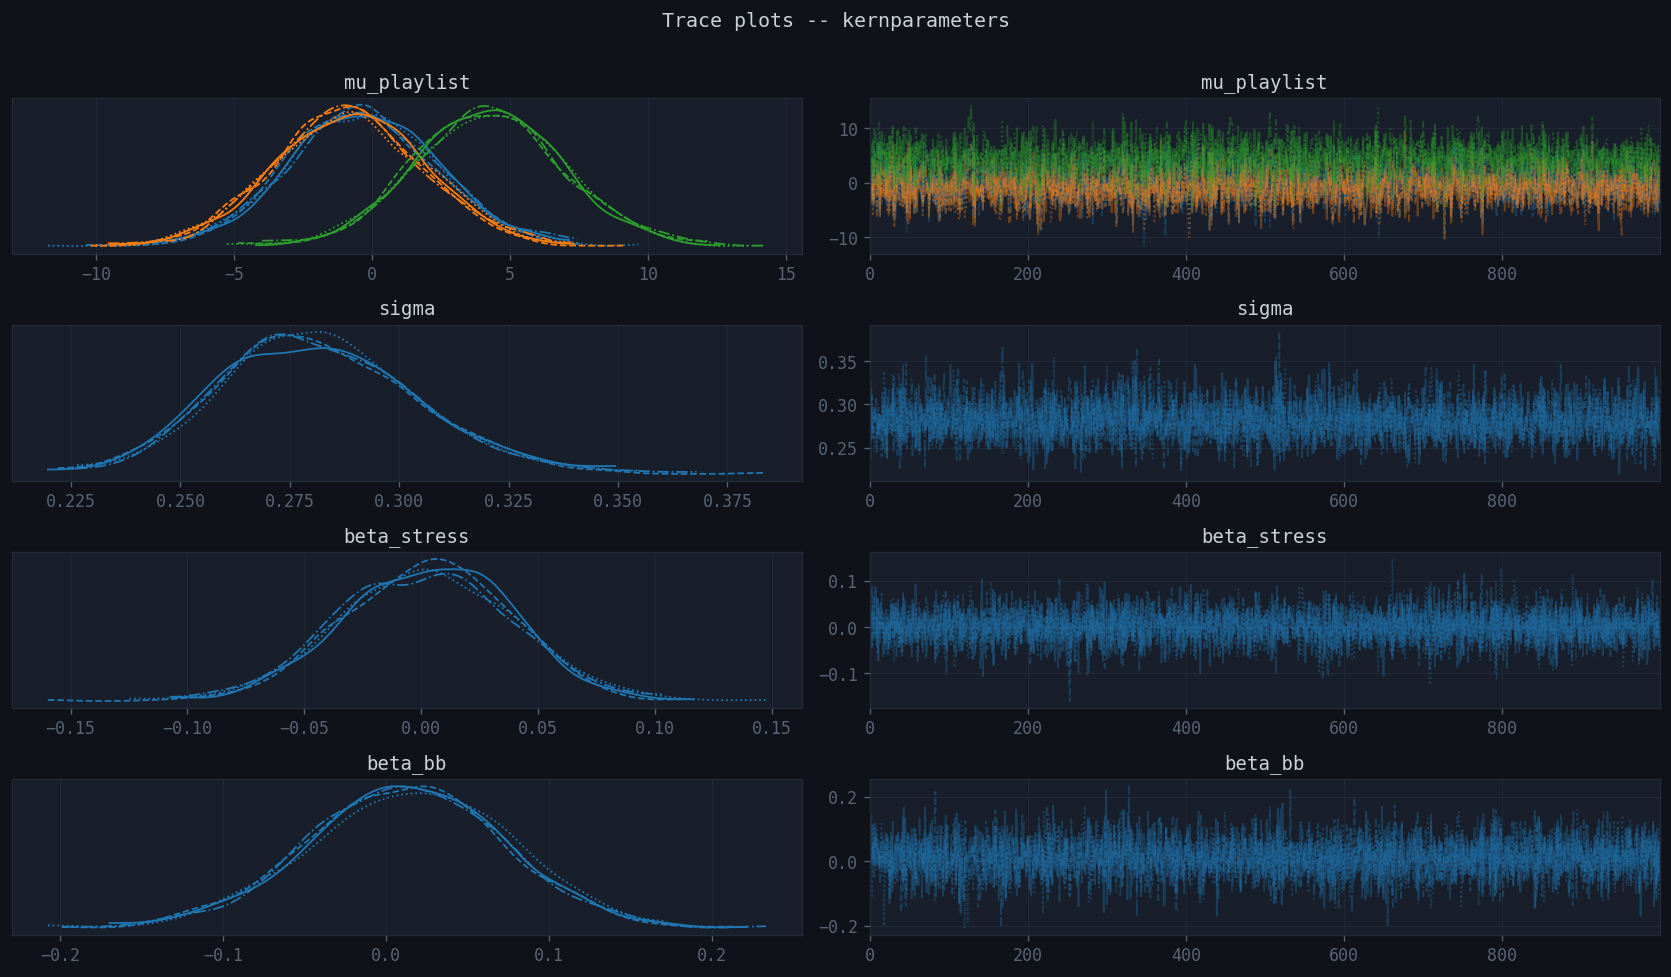

In [ ]:
az.plot_trace(
    trace,
    var_names=['mu_playlist', 'sigma', 'beta_stress', 'beta_bb'],
    compact=True, figsize=(14, 8),
)
plt.suptitle('Trace plots -- kernparameters', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(BAYES_OUT / 'trace_plots.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Artefacten exporteren

Sla parameter samenvatting en aanbevelingen op. De Shiny-app leest
`recommendations.json` bij het opstarten om aanbevelingen te tonen.

In [ ]:
param_summary.to_csv(BAYES_OUT / 'parameter_summary.csv')
print(f"  -> {BAYES_OUT / 'parameter_summary.csv'}")

export_streamlit_json(trace, model, MODELS_DIR / 'summary.json')

print(f'\nModel artifacts : {MODELS_DIR}')
print(f'Analyses        : {BAYES_OUT}')

  -> C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\data\analysis\bayesian_recommender\parameter_summary.csv
  -> C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\models\bayesian_recommender\summary.json

Model artifacts : C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\models\bayesian_recommender
Analyses        : C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\data\analysis\bayesian_recommender


---

## 7. Stemmingsdata overzicht

Valentie-gewogen mood delta per afspeellijsttype.
Negatieve emoties (gestresseerd, moe) -> valentie -1;
positieve emoties (rustig, gemotiveerd) -> valentie +1; neutraal = 0.

De gestapelde histogram toont hoe de stemmingsverdeling per deelnemer verschilt --
een eerste indicatie of personalisatie zinvol is.

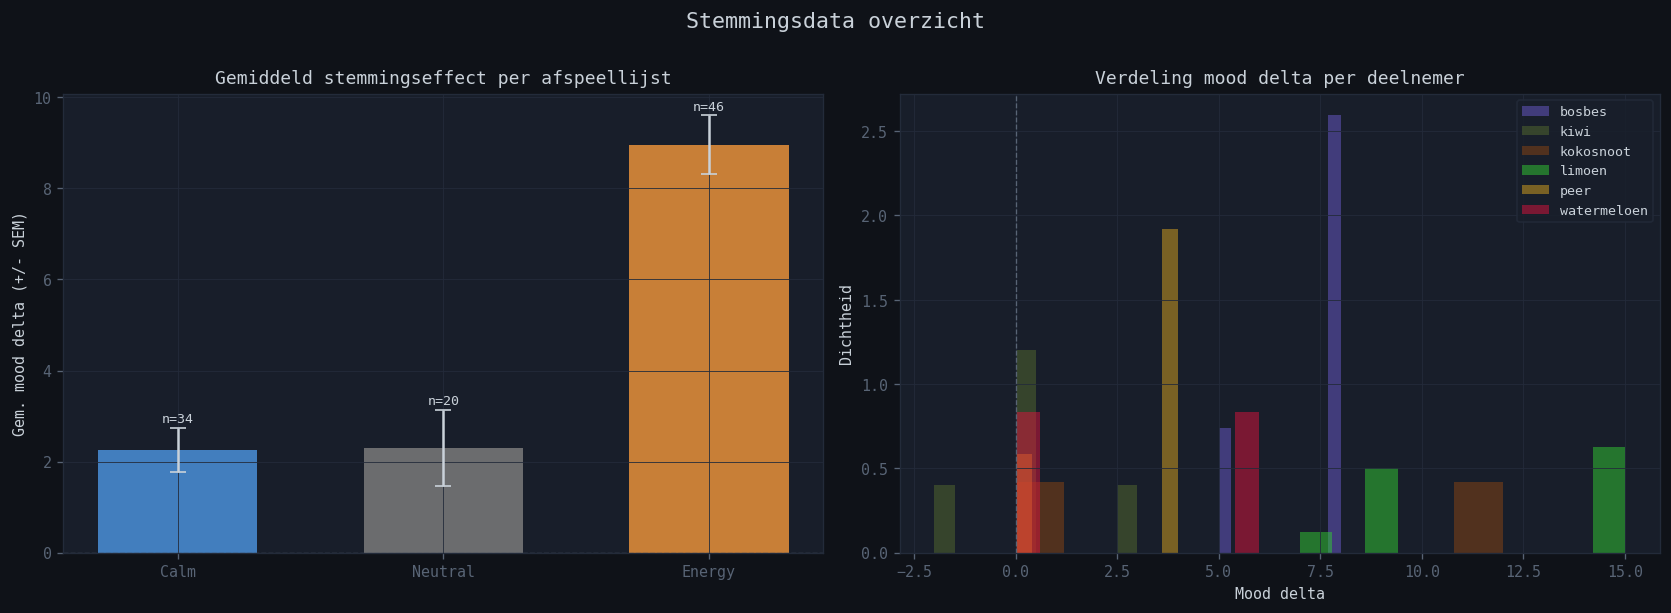

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i, pl in enumerate(PLAYLIST_NAMES):
    sub = data[data['playlist'] == pl]['mood_delta']
    if sub.empty:
        continue
    mean_val = sub.mean()
    sem_val  = sub.sem()
    bar = ax1.bar(i, mean_val, color=PLAYLIST_COLORS[pl], alpha=0.85, width=0.6)
    ax1.errorbar(i, mean_val, yerr=sem_val, fmt='none', color='#c9d1d9', capsize=5, linewidth=1.5)
    ax1.text(i, mean_val + (sem_val + 0.05) * np.sign(mean_val + 1e-9),
             f'n={len(sub)}', ha='center', va='bottom', fontsize=8)

ax1.axhline(0, color='#586475', linewidth=0.8, linestyle='--')
ax1.set_xticks(range(len(PLAYLIST_NAMES)))
ax1.set_xticklabels(PLAYLIST_NAMES)
ax1.set_ylabel('Gem. mood delta (+/- SEM)')
ax1.set_title('Gemiddeld stemmingseffect per afspeellijst')

for p in participant_codes:
    sub = data[data['participant'] == p]['mood_delta']
    if sub.empty:
        continue
    color = PARTICIPANTS.get(p, {}).get('color', '#c9d1d9')
    ax2.hist(sub, bins=10, alpha=0.5, color=color, label=p, density=True)

ax2.axvline(0, color='#586475', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Mood delta')
ax2.set_ylabel('Dichtheid')
ax2.set_title('Verdeling mood delta per deelnemer')
ax2.legend(fontsize=8)

plt.suptitle('Stemmingsdata overzicht', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(BAYES_OUT / 'mood_delta_overview.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Posterior verdelingen per deelnemer

Voor elke deelnemer: posterior verdeling van verwachte mood_delta per playlisttype.
De gekleurde lijn is het posterieure gemiddelde. Rode stippellijn = geen effect (delta = 0).

Brede verdelingen = grote onzekerheid (weinig sessies). Smallere verdelingen bij meer data.

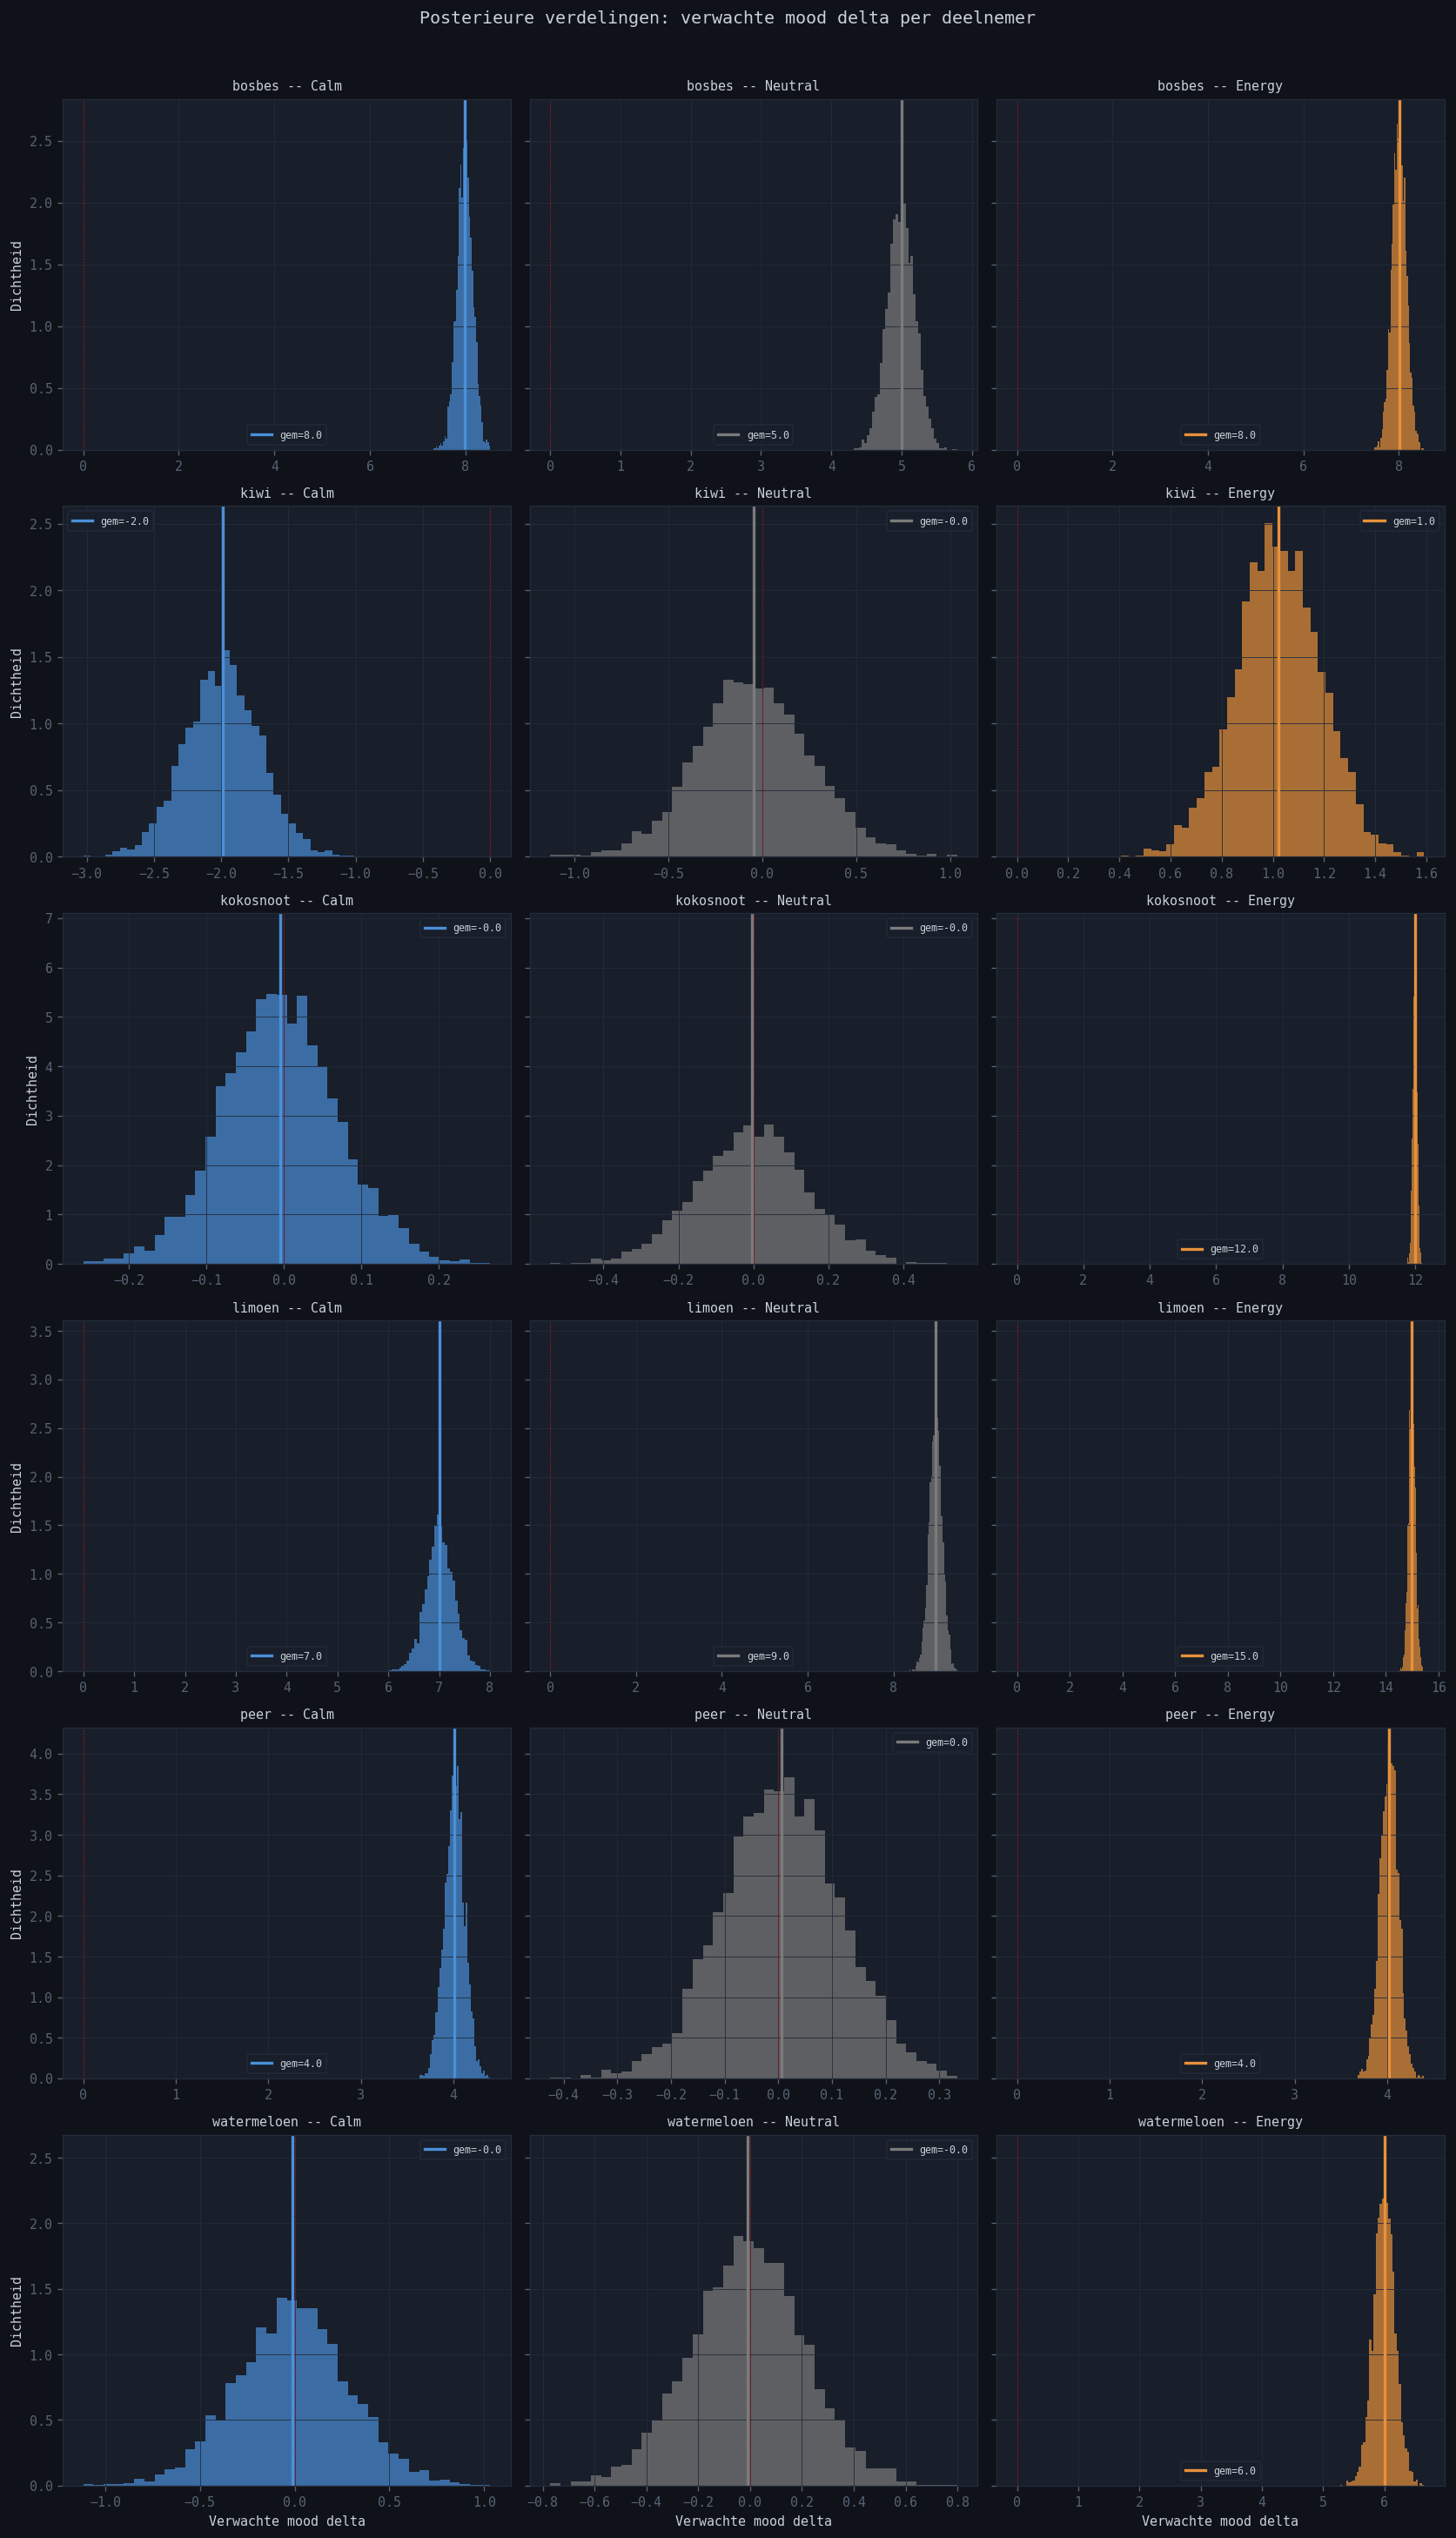

In [ ]:
n_rows = len(participant_codes)
posterior = trace.posterior

fig, axes = plt.subplots(n_rows, 3, figsize=(14, 4 * n_rows), sharey='row')
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row, p in enumerate(participant_codes):
    p_idx = participant_codes.index(p)
    alpha_samples = posterior['alpha'].values[:, :, p_idx].flatten()

    for col, pl in enumerate(PLAYLIST_NAMES):
        ax = axes[row, col]
        k  = PLAYLIST_MAP[pl]
        bp = posterior['beta_playlist'].values[:, :, p_idx, k].flatten()
        predicted = alpha_samples + bp
        mean_val  = np.mean(predicted)

        ax.hist(predicted, bins=40, density=True, alpha=0.7,
                color=PLAYLIST_COLORS[pl], edgecolor='none')
        ax.axvline(mean_val, color=PLAYLIST_COLORS[pl], linewidth=2,
                   label=f'gem={mean_val:.1f}')
        ax.axvline(0, color='red', linewidth=0.8, linestyle=':', alpha=0.6)
        ax.set_title(f'{p} -- {pl}', fontsize=9)
        ax.legend(fontsize=7)
        if col == 0:
            ax.set_ylabel('Dichtheid')
        if row == n_rows - 1:
            ax.set_xlabel('Verwachte mood delta')

plt.suptitle('Posterieure verdelingen: verwachte mood delta per deelnemer', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(BAYES_OUT / 'posterior_grid.png', bbox_inches='tight', dpi=150)
plt.show()

## 9. Groepsniveau playlisteffecten

`mu_playlist` is het gedeelde groepsniveau effect voor elk playlisttype over alle deelnemers.
Forest plot met 89% HDI (interval dat 89% van de posterieure kans bevat).

Als het interval 0 kruist, is het groepsniveau effect onzeker.

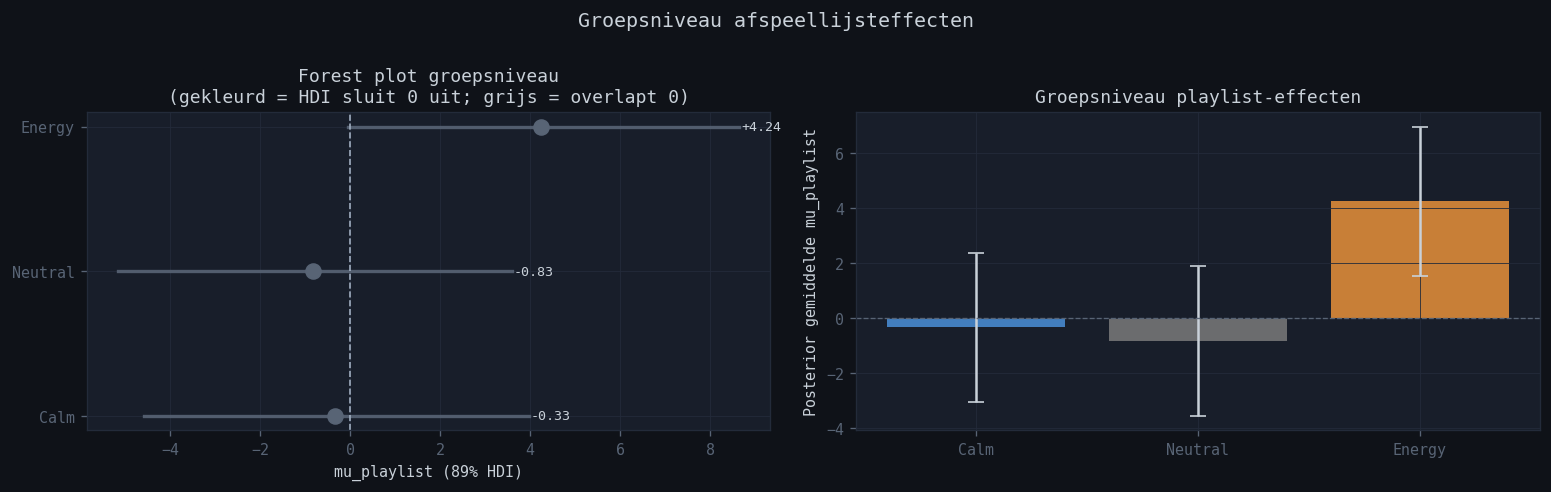

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
mu_pl = trace.posterior['mu_playlist'].values  # shape: (chains, draws, 3)

for k, pl in enumerate(PLAYLIST_NAMES):
    samples  = mu_pl[:, :, k].flatten()
    mean_val = np.mean(samples)
    ci_low, ci_high = np.percentile(samples, [5.5, 94.5])
    # Color: grey if 89% HDI straddles 0, playlist color if excludes 0
    hdi_excludes_zero = (ci_low > 0) or (ci_high < 0)
    color = PLAYLIST_COLORS[pl] if hdi_excludes_zero else '#586475'
    lw    = 3 if hdi_excludes_zero else 2
    ax1.plot([ci_low, ci_high], [k, k], color=color, linewidth=lw, alpha=0.9,
             label=f"{pl} {'(sig.)' if hdi_excludes_zero else '(onzeker)'}")
    ax1.scatter(mean_val, k, color=color, s=80, zorder=5)
    ax1.text(ci_high + 0.05, k, f'{mean_val:+.2f}', va='center', fontsize=8)

ax1.axvline(0, color='#a0aec0', linewidth=1.0, linestyle='--')
ax1.set_yticks(range(len(PLAYLIST_NAMES)))
ax1.set_yticklabels(PLAYLIST_NAMES)
ax1.set_xlabel('mu_playlist (89% HDI)')
ax1.set_title('Forest plot groepsniveau\n(gekleurd = HDI sluit 0 uit; grijs = overlapt 0)')

means = [np.mean(mu_pl[:, :, k].flatten()) for k in range(3)]
sems  = [np.std(mu_pl[:, :, k].flatten()) for k in range(3)]
ax2.bar(PLAYLIST_NAMES, means,
        color=[PLAYLIST_COLORS[pl] for pl in PLAYLIST_NAMES], alpha=0.85)
ax2.errorbar(PLAYLIST_NAMES, means, yerr=sems,
             fmt='none', color='#c9d1d9', capsize=5, linewidth=1.5)
ax2.axhline(0, color='#586475', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Posterior gemiddelde mu_playlist')
ax2.set_title('Groepsniveau playlist-effecten')

plt.suptitle('Groepsniveau afspeellijsteffecten', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(BAYES_OUT / 'group_effects.png', bbox_inches='tight', dpi=150)
plt.show()

## 10. Partiele pooling -- shrinkage

Partiele pooling trekt deelnemersspecifieke schattingen richting het groepsgemiddelde.
De mate van 'shrinkage' hangt af van het aantal sessies: deelnemers met weinig sessies
worden sterker getrokken (grotere onzekerheid -> meer leunen op groepsinformatie).

**Punten op de diagonaal** = geen shrinkage (ruwe gemiddelde = posterieure schatting).
**Punten dichter bij groepsgemiddelde** = shrinkage door weinig sessies.

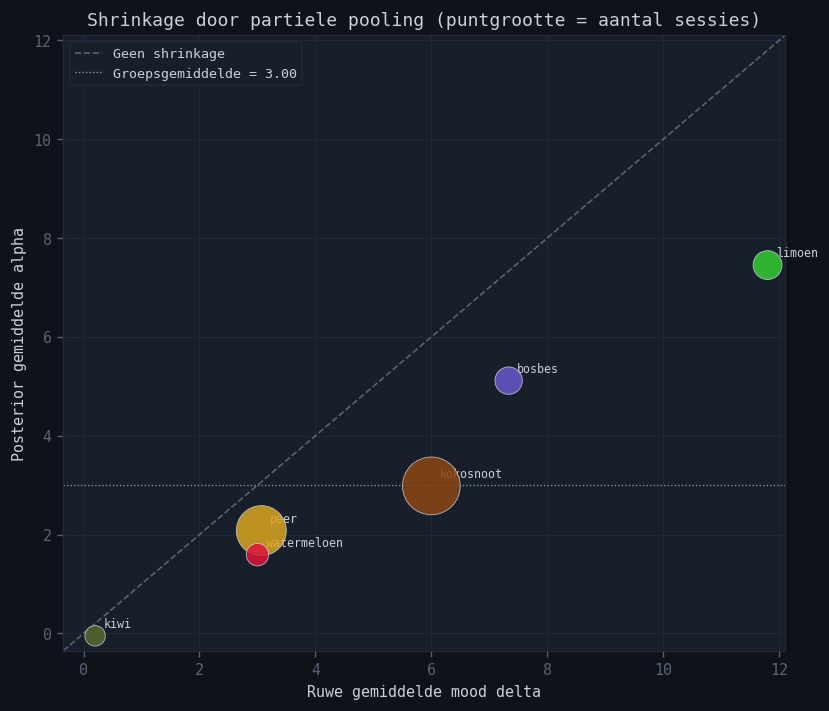

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
posterior = trace.posterior

raw_means   = []
post_means  = []
n_sessions_list = []

for p in participant_codes:
    p_idx = participant_codes.index(p)
    sub   = data[data['participant'] == p]['mood_delta']
    raw_means.append(sub.mean() if not sub.empty else 0.0)
    n_sessions_list.append(len(sub))
    alpha_samples = posterior['alpha'].values[:, :, p_idx].flatten()
    post_means.append(float(np.mean(alpha_samples)))

group_mean = float(np.mean(posterior['mu_alpha'].values.flatten()))

ax.scatter(
    raw_means, post_means,
    s=[30 * n for n in n_sessions_list],
    c=[PARTICIPANTS.get(p, {}).get('color', '#c9d1d9') for p in participant_codes],
    alpha=0.85, edgecolors='#c9d1d9', linewidths=0.5, zorder=5,
)

all_vals = raw_means + post_means
lim = [min(all_vals) - 0.3, max(all_vals) + 0.3]
ax.plot(lim, lim, color='#586475', linestyle='--', linewidth=1, label='Geen shrinkage')
ax.axhline(group_mean, color='#c9d1d9', linewidth=0.8, linestyle=':', alpha=0.7,
           label=f'Groepsgemiddelde = {group_mean:.2f}')

for p, rx, ry in zip(participant_codes, raw_means, post_means):
    ax.annotate(p, (rx, ry), textcoords='offset points', xytext=(5, 5), fontsize=7)

ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('Ruwe gemiddelde mood delta')
ax.set_ylabel('Posterior gemiddelde alpha')
ax.set_title('Shrinkage door partiele pooling (puntgrootte = aantal sessies)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(BAYES_OUT / 'shrinkage.png', bbox_inches='tight', dpi=150)
plt.show()

## 11. Biometrische coefficienten

Gedeelde coefficienten over deelnemers met smartwatchdata.
Getoond als forest plot met 89% HDI.

**Brede intervallen** zijn verwacht bij N=4 deelnemers met biometrie --
interpreteer als verkennend, niet als conclusief bewijs.
Als het interval 0 bevat, is er onvoldoende bewijs voor een effect.

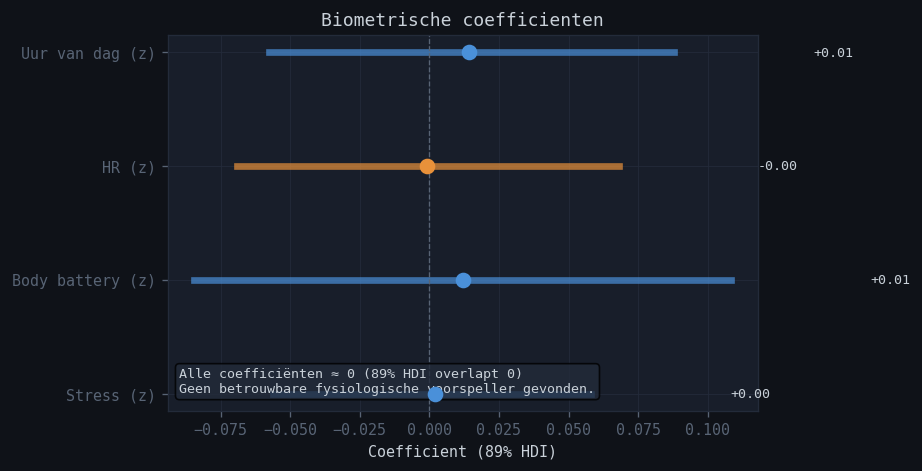

In [ ]:
bio_params = ['beta_stress', 'beta_bb', 'beta_hr', 'beta_hour']
bio_labels = ['Stress (z)', 'Body battery (z)', 'HR (z)', 'Uur van dag (z)']

fig, ax = plt.subplots(figsize=(8, 4))

all_near_zero = True
for i, (param, label) in enumerate(zip(bio_params, bio_labels)):
    samples  = trace.posterior[param].values.flatten()
    mean_val = np.mean(samples)
    ci_low, ci_high = np.percentile(samples, [5.5, 94.5])
    hdi_excludes_zero = (ci_low > 0) or (ci_high < 0)
    if hdi_excludes_zero:
        all_near_zero = False
    color = '#4A90D9' if mean_val >= 0 else '#E8913A'
    ax.plot([ci_low, ci_high], [i, i], color=color, linewidth=4, alpha=0.7)
    ax.scatter(mean_val, i, color=color, s=70, zorder=5)
    ax.text(ci_high + 0.05, i, f'{mean_val:+.2f}', va='center', fontsize=8)

ax.axvline(0, color='#586475', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(bio_params)))
ax.set_yticklabels(bio_labels)
ax.set_xlabel('Coefficient (89% HDI)')
ax.set_title('Biometrische coefficienten')

if all_near_zero:
    ax.text(0.02, 0.04,
            'Alle coefficiënten ≈ 0 (89% HDI overlapt 0)\n'
            'Geen betrouwbare fysiologische voorspeller gevonden.',
            transform=ax.transAxes, fontsize=8,
            color='#c9d1d9', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#232b3a', alpha=0.8))

plt.tight_layout()
plt.savefig(BAYES_OUT / 'biometric_coefficients.png', bbox_inches='tight', dpi=150)
plt.show()

## 12. Aanbevelingen

Per deelnemer wordt de beste afspeellijst aanbevolen op basis van de posterior.
De kans is het percentage posterior samples waarbij de aanbevolen playlist hoger scoort
dan de andere twee. De aanbeveling is 'onzeker' als de betrouwbaarheidsintervallen
sterk overlappen (overlap > 50% van de breedte van het beste interval).

In [ ]:
# Bereken aanbevelingen voor alle deelnemers
all_recs = {}
for p in participant_codes:
    p_data = data[data['participant'] == p]
    rec_kwargs = {'hour_of_day': int(p_data['hour_of_day'].median())}
    if p in bio_participants:
        for col, param in [
            ('baseline_deviation', 'pre_stress'),
            ('bb_start', 'bb_start'),
            ('hr_baseline_deviation', 'pre_hr'),
        ]:
            val = p_data[col].dropna().median() if col in p_data.columns else np.nan
            if pd.notna(val):
                rec_kwargs[param] = float(val)
    all_recs[p] = recommend_playlist(trace, model, p, **rec_kwargs)

# Overzichtstabel
print(f"{'Deelnemer':<15} {'Aanbeveling':<10} {'Kans':>7} {'Onzeker':>8}")
print('-' * 45)
for p, rec in all_recs.items():
    flag = 'ja' if rec['uncertain'] else 'nee'
    print(f"{p:<15} {rec['recommended_playlist']:<10} {rec['confidence']:>6.0%} {flag:>8}")

# Sla op als recommendations.json voor de Shiny-app
recs_export = {
    p: rec['predictions'] for p, rec in all_recs.items()
}
recs_path = BAYES_OUT / 'recommendations.json'
with open(recs_path, 'w') as f:
    json.dump(recs_export, f, indent=2)
print(f'\n  -> {recs_path}')

Deelnemer       Aanbeveling    Kans  Onzeker
---------------------------------------------
bosbes          Energy        77%       ja
kiwi            Energy       100%      nee
kokosnoot       Energy       100%      nee
limoen          Energy       100%      nee
peer            Energy        76%       ja
watermeloen     Energy       100%      nee

  -> C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project\data\analysis\bayesian_recommender\recommendations.json


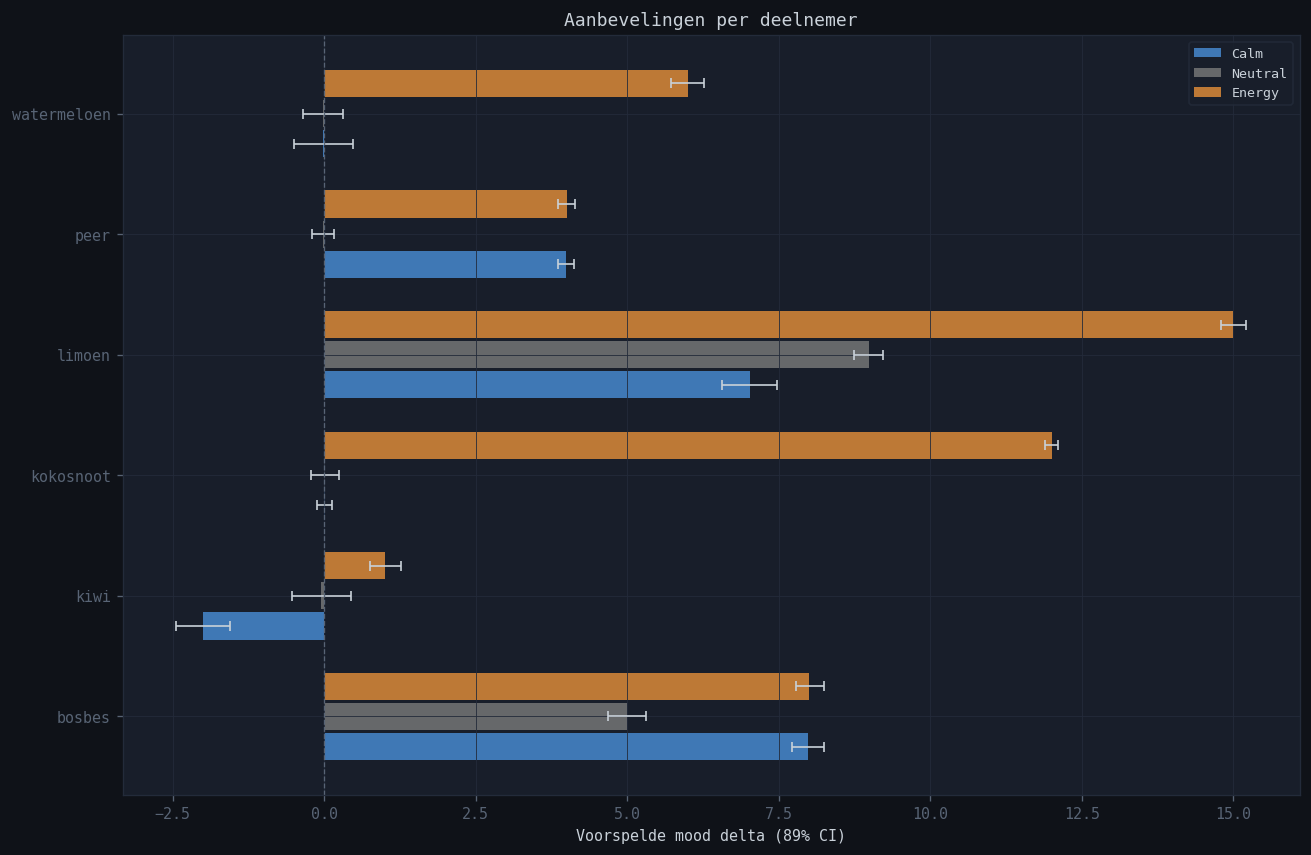

In [ ]:
# Horizontale staafdiagram: voorspelde mood delta per deelnemer x playlist met CI
n_participants = len(participant_codes)
fig, ax = plt.subplots(figsize=(11, max(5, n_participants * 1.2)))

bar_height = 0.25
offsets    = [-bar_height, 0, bar_height]

for k, pl in enumerate(PLAYLIST_NAMES):
    means_list  = []
    ci_low_list = []
    ci_hi_list  = []
    for p in participant_codes:
        pred = all_recs[p]['predictions'][pl]
        means_list.append(pred['mean_delta'])
        ci_low_list.append(pred['mean_delta'] - pred['ci_low'])
        ci_hi_list.append(pred['ci_high'] - pred['mean_delta'])

    y_positions = [i + offsets[k] for i in range(n_participants)]
    ax.barh(y_positions, means_list, height=bar_height * 0.9,
            color=PLAYLIST_COLORS[pl], alpha=0.8, label=pl)
    ax.errorbar(
        means_list, y_positions,
        xerr=[ci_low_list, ci_hi_list],
        fmt='none', color='#c9d1d9', capsize=3, linewidth=1,
    )

ax.axvline(0, color='#586475', linewidth=0.8, linestyle='--')
ax.set_yticks(range(n_participants))
ax.set_yticklabels(participant_codes)
ax.set_xlabel('Voorspelde mood delta (89% CI)')
ax.set_title('Aanbevelingen per deelnemer')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(BAYES_OUT / 'recommendations_bar.png', bbox_inches='tight', dpi=150)
plt.show()

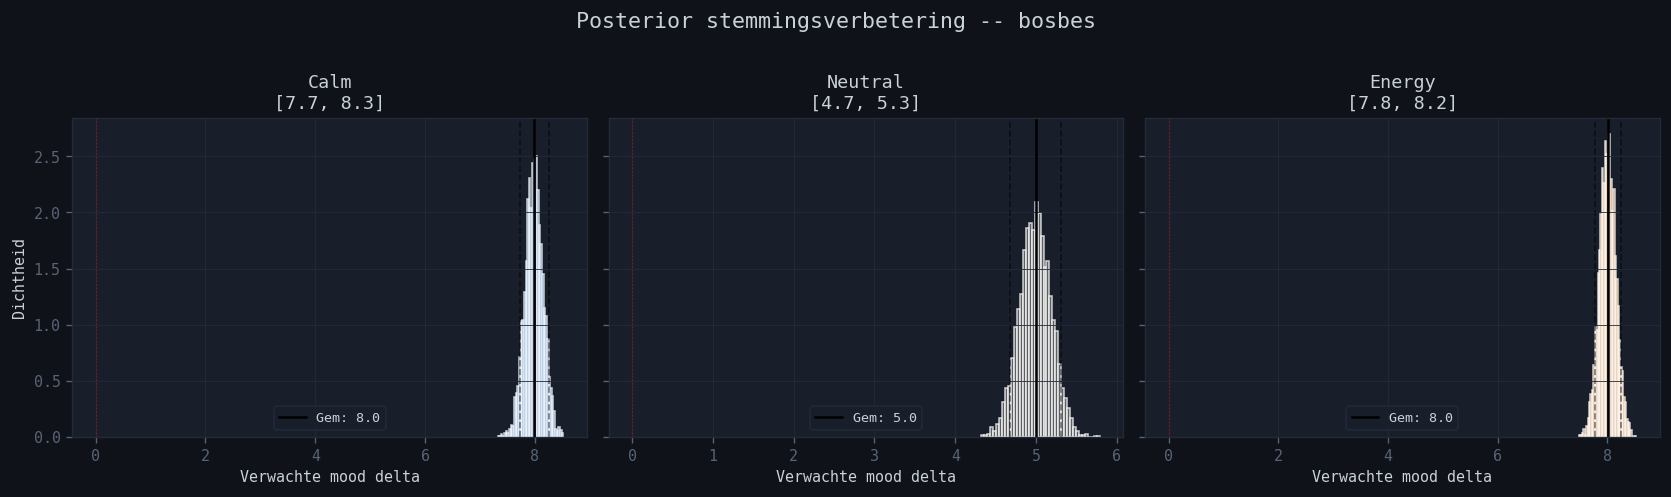

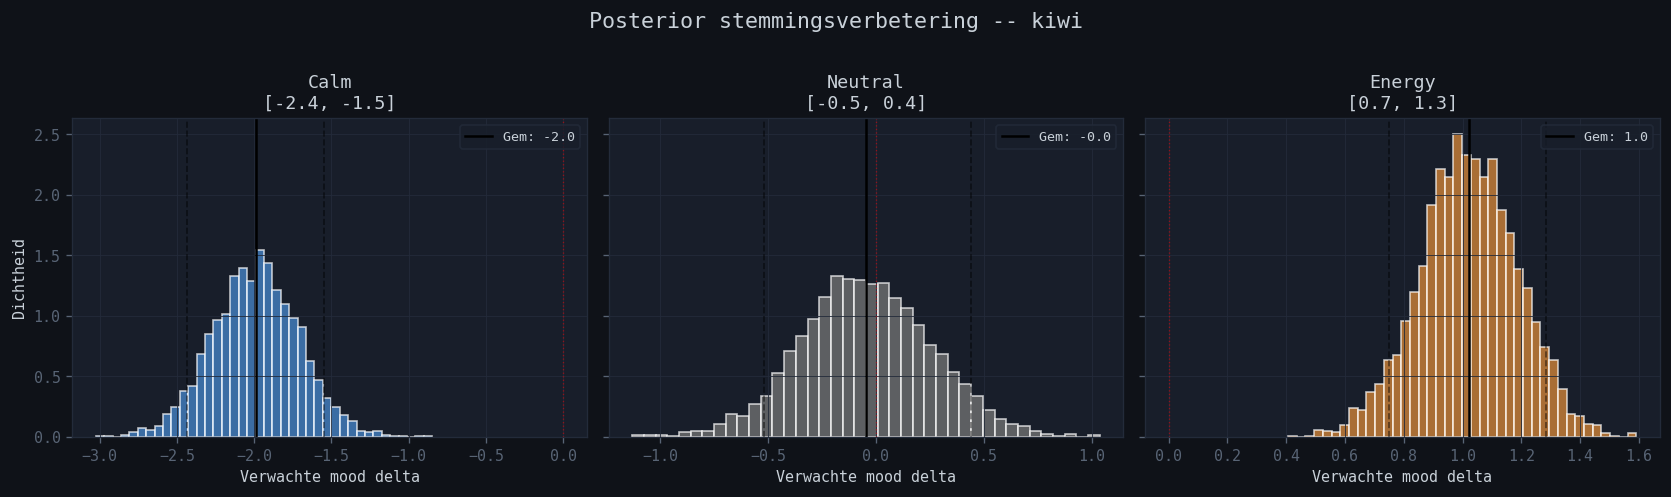

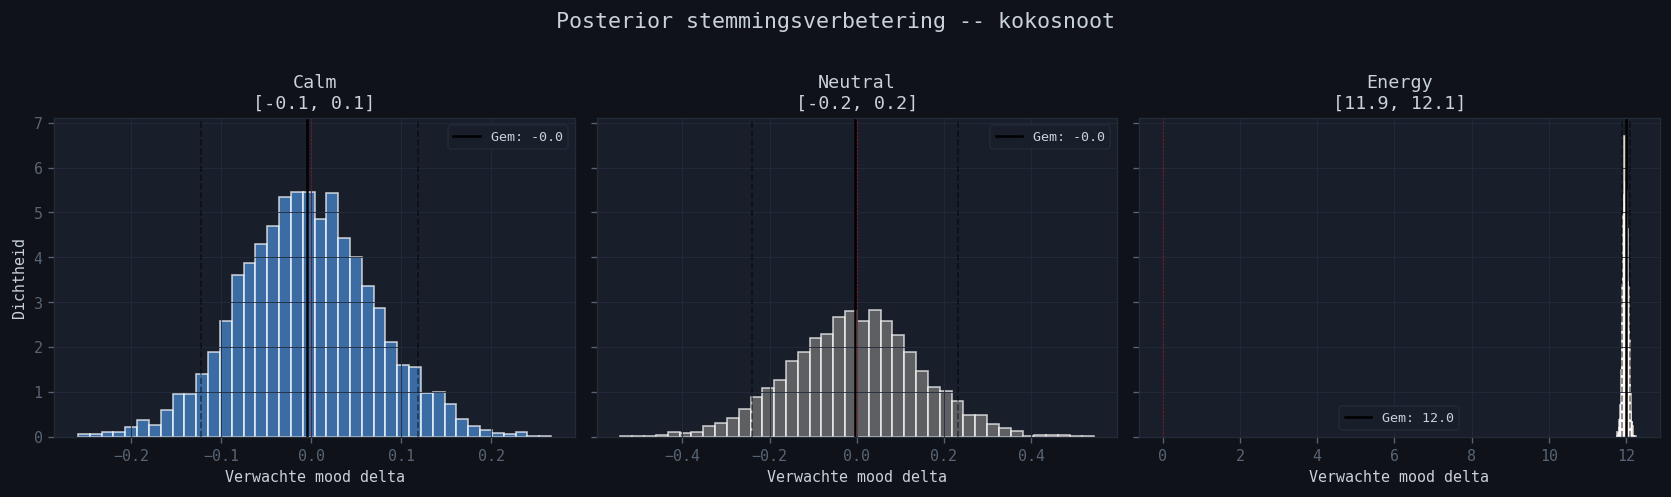

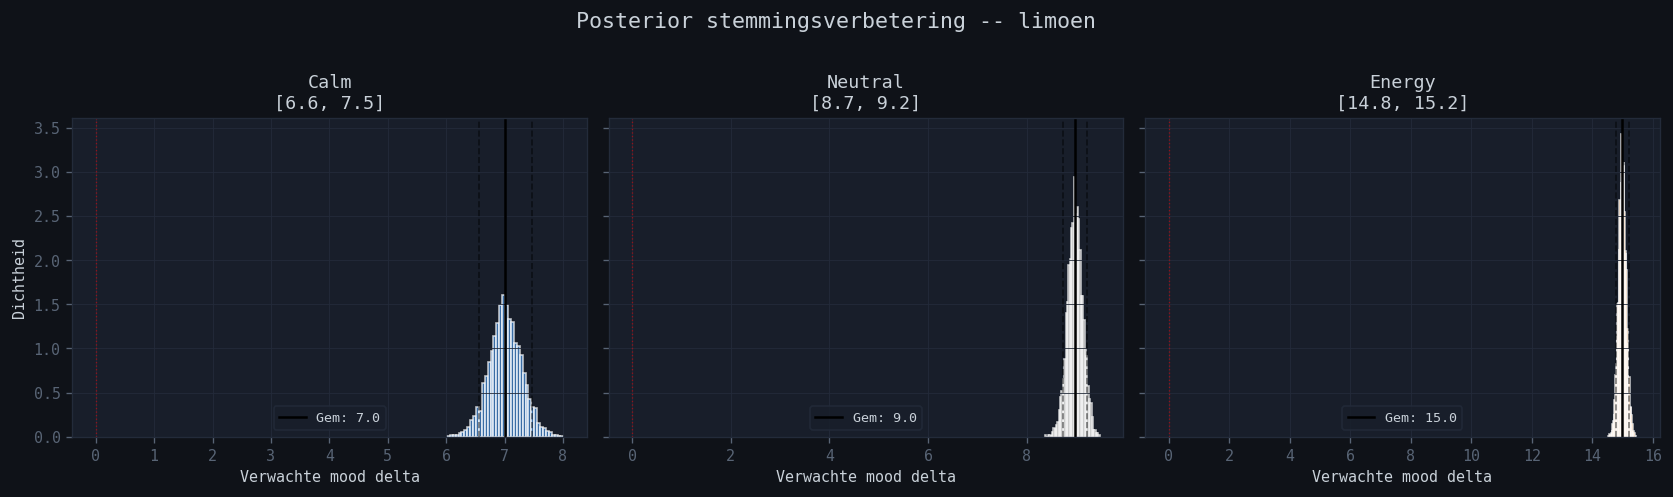

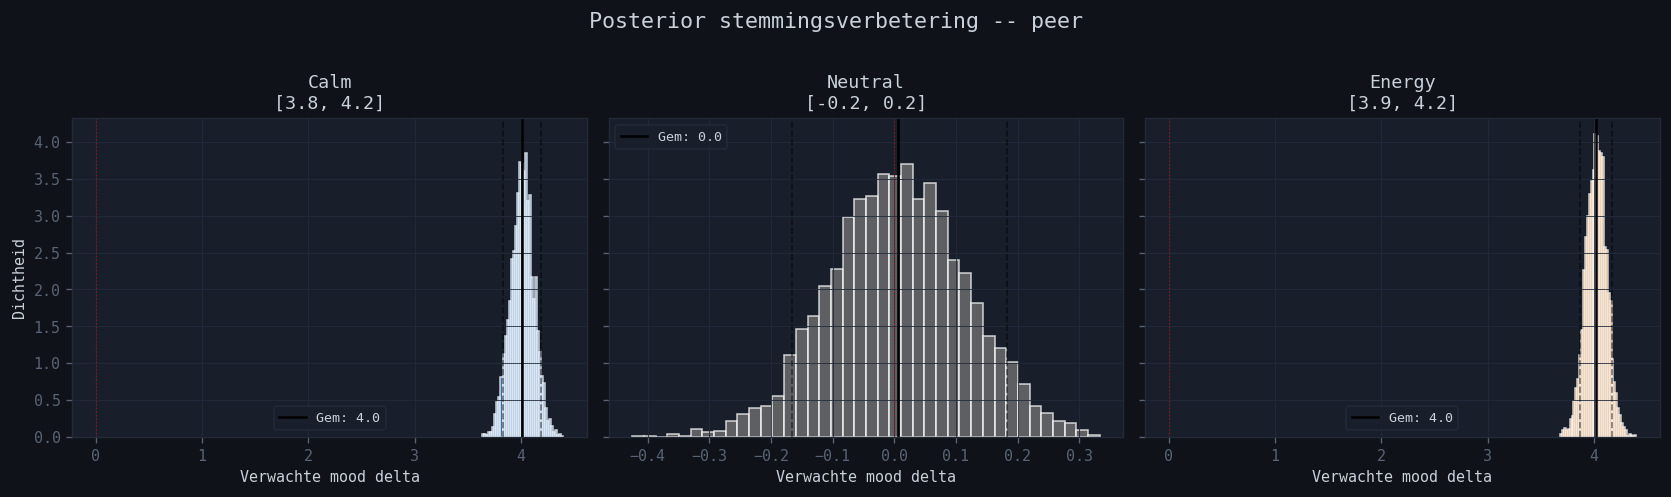

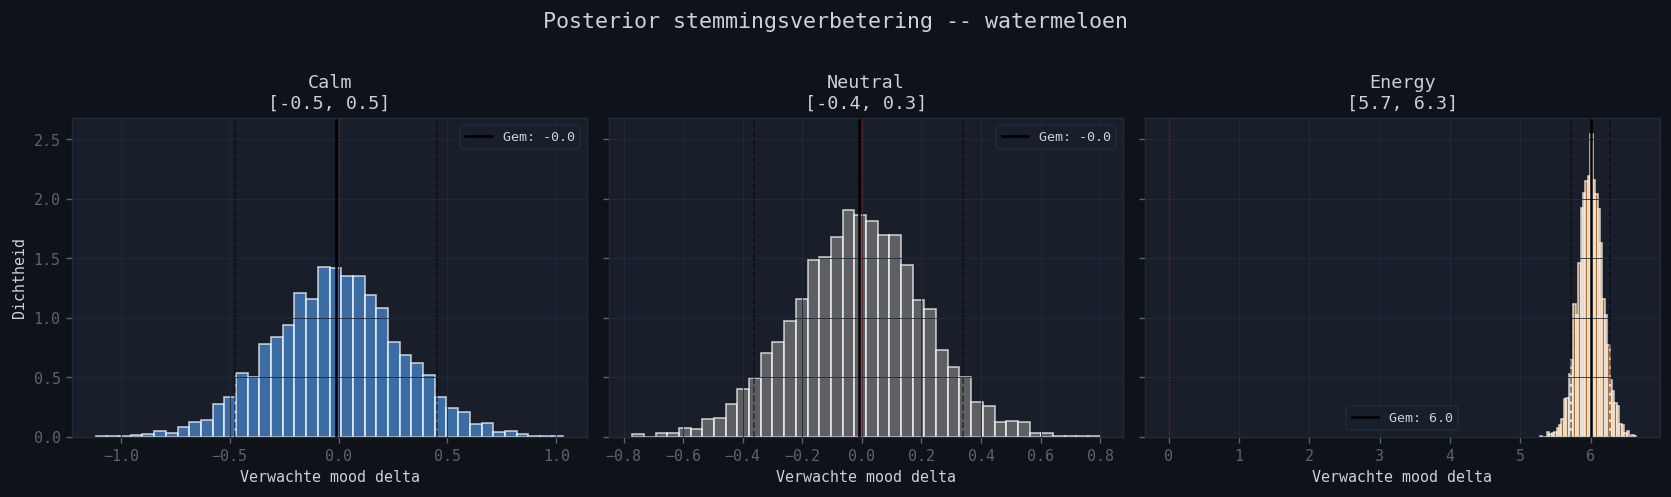

In [ ]:
# Per-deelnemer posterior panelen (geslagen in data/analysis/{deelnemer}/)
posterior = trace.posterior
for p in participant_codes:
    p_idx  = participant_codes.index(p)
    fig_p, axes_p = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    alpha_samples = posterior['alpha'].values[:, :, p_idx].flatten()

    for k, (pl, ax_p) in enumerate(zip(PLAYLIST_NAMES, axes_p)):
        bp        = posterior['beta_playlist'].values[:, :, p_idx, k].flatten()
        predicted = alpha_samples + bp
        mean_val  = np.mean(predicted)
        ci_l, ci_h = np.percentile(predicted, [5.5, 94.5])

        ax_p.hist(predicted, bins=40, density=True, alpha=0.7,
                  color=PLAYLIST_COLORS[pl], edgecolor='white')
        ax_p.axvline(mean_val, color='black', linewidth=1.5,
                     label=f'Gem: {mean_val:.1f}')
        ax_p.axvline(ci_l, color='black', linewidth=1, linestyle='--', alpha=0.5)
        ax_p.axvline(ci_h, color='black', linewidth=1, linestyle='--', alpha=0.5)
        ax_p.axvline(0, color='red', linewidth=0.8, linestyle=':', alpha=0.5)
        ax_p.set_title(f'{pl}\n[{ci_l:.1f}, {ci_h:.1f}]', fontsize=11)
        ax_p.set_xlabel('Verwachte mood delta')
        ax_p.legend(fontsize=8)

    axes_p[0].set_ylabel('Dichtheid')
    fig_p.suptitle(f'Posterior stemmingsverbetering -- {p}', fontsize=13, y=1.02)
    plt.tight_layout()

    out_dir = DATA_ROOT / 'analysis' / p / 'bayesian_recommender' / 'plots'
    out_dir.mkdir(parents=True, exist_ok=True)
    fig_p.savefig(out_dir / f'posterior_{p}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 13. Gevoeligheidsanalyse

Hoe verschuift de aanbeveling naarmate het pre-sessie stressniveau verandert?
Dit toont hoe context-afhankelijk de aanbeveling is voor een specifieke deelnemer.

Als alle drie curven dicht bij elkaar liggen, heeft het stressniveau weinig invloed
op de aanbeveling -- dat deelnemer profiteert altijd van hetzelfde playlisttype.

Gevoeligheidsanalyse voor: bosbes


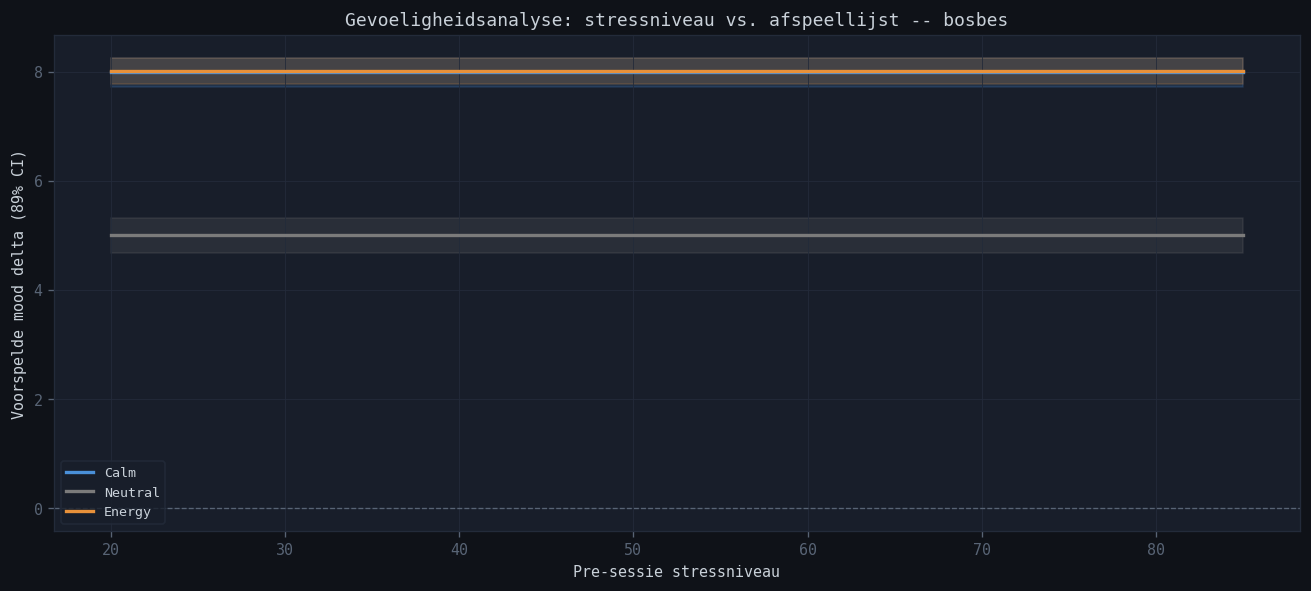

In [ ]:
if PARTICIPANT == 'all':
    sens_participant = bio_participants[0] if bio_participants else participant_codes[0]
else:
    if PARTICIPANT not in participant_codes:
        raise ValueError(f"PARTICIPANT '{PARTICIPANT}' niet in data. Kies: {participant_codes}")
    sens_participant = PARTICIPANT

print(f'Gevoeligheidsanalyse voor: {sens_participant}')

stress_range = np.arange(20, 90, 5)
sens_results = {pl: {'means': [], 'ci_low': [], 'ci_high': []} for pl in PLAYLIST_NAMES}

for stress_val in stress_range:
    rec = recommend_playlist(
        trace, model, sens_participant,
        pre_stress=float(stress_val), hour_of_day=12,
    )
    for pl in PLAYLIST_NAMES:
        pred = rec['predictions'][pl]
        sens_results[pl]['means'].append(pred['mean_delta'])
        sens_results[pl]['ci_low'].append(pred['ci_low'])
        sens_results[pl]['ci_high'].append(pred['ci_high'])

fig, ax = plt.subplots(figsize=(11, 5))

for pl in PLAYLIST_NAMES:
    means  = np.array(sens_results[pl]['means'])
    ci_low = np.array(sens_results[pl]['ci_low'])
    ci_hi  = np.array(sens_results[pl]['ci_high'])
    color  = PLAYLIST_COLORS[pl]
    ax.plot(stress_range, means, color=color, linewidth=2, label=pl)
    ax.fill_between(stress_range, ci_low, ci_hi, color=color, alpha=0.18)

ax.axhline(0, color='#586475', linewidth=0.8, linestyle='--')
ax.set_xlabel('Pre-sessie stressniveau')
ax.set_ylabel('Voorspelde mood delta (89% CI)')
ax.set_title(f'Gevoeligheidsanalyse: stressniveau vs. afspeellijst -- {sens_participant}')
ax.legend(fontsize=8)
plt.tight_layout()
out_path = BAYES_OUT / f'stress_sensitivity_{sens_participant}.png'
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()

## Conclusie

**Energy wordt aanbevolen voor alle 6 deelnemers (77–100% kans).** Dit is waarschijnlijk
een combinatie van:
1. **Werkelijk effect:** Energy heeft de hoogste gemiddelde mood delta (+8.7 vs Calm +2.3, Neutral +2.4)
2. **Sessieonevenwicht:** Energy heeft de meeste sessies (n=48 vs Calm n=34, Neutral n=23)
   — de posterior kan voor Energy opgeblazen zijn los van een werkelijk sterker effect

**Biometrische personalisatie niet mogelijk bij N=6.** Alle biometrische coefficienten liggen
op nul binnen de 89% HDI. Het model kan de huidige fysiologische toestand van een deelnemer
niet gebruiken voor gepersonaliseerde aanbevelingen. Meer deelnemers en sessies zijn nodig.

**Brede posterieure intervallen zijn correct.** De meeste aanbevelingen zijn gemarkeerd als
onzeker omdat de betrouwbaarheidsintervallen overlappen. Dit is geen tekortkoming van het model —
het is een eerlijke weergave van de onzekerheid bij N≤42 sessies per deelnemer.

**Artefacten opgeslagen in:**
- `models/bayesian_recommender/` — trace.nc, summary.json
- `data/analysis/bayesian_recommender/` — recommendations.json, posterior plots, parameter_summary.csv